### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


# Atif's assignment starts here

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt

### Observing the data

Below, we will load the `.csv` file and create a data frame. We will look at the shape, columns, and descriptive statistics.

In [67]:
df_grades = pd.read_csv("grades_crpt.csv")
display(df_grades)
display (f"The shape of the dataframe is: {df_grades.shape}")
columns = [*df_grades.columns]
print(f"Columns are: {columns}")
print("\nGiven below are descriptive stats on the numerical columns\n")
df_grades.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


'The shape of the dataframe is: (86, 9)'

Columns are: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam', 'user_id']

Given below are descriptive stats on the numerical columns



,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


Observing the dataframe, this is what we know:

- There are 86 rows (85 entries because the first row is column header)
- There are 9 columns. 7 assignments + final exam + user id
- There are a few missing values in the assignment columns. I will show the exact number below using python code.
- Using the descriptive stats table, I can see negative values for A1, A2, A3, A4, and A6.
- A2 max should be 100 + 15 = 115, but we see a max of 148.9. This is unusual.
- A4 max should be 100 + 4 = 104, but we see a max of 188.2. This is unusual.
- A6 max should be 100 + 10 = 110, but we see 183.6. This is unusual.

Below, let us count the number of missing values.

In [68]:
a1_missing = df_grades["A1"].isnull().sum()
a2_missing = df_grades["A2"].isnull().sum()
a3_missing = df_grades["A3"].isnull().sum()
a4_missing = df_grades["A4"].isnull().sum()
a5_missing = df_grades["A5"].isnull().sum()
a6_missing = df_grades["A6"].isnull().sum()
a7_missing = df_grades["A7"].isnull().sum()
final_missing = df_grades["Final_Exam"].isnull().sum()
id_missing = df_grades["user_id"].isnull().sum()

print(f"There are {a1_missing} missing values in A1 column")
print(f"There are {a2_missing} missing values in A2 column")
print(f"There are {a3_missing} missing values in A3 column")
print(f"There are {a4_missing} missing values in A4 column")
print(f"There are {a5_missing} missing values in A5 column")
print(f"There are {a6_missing} missing values in A6 column")
print(f"There are {a7_missing} missing values in A7 column")
print(f"There are {final_missing} missing values in final column")
print(f"There are {id_missing} missing values in user id column")



There are 29 missing values in A1 column
There are 25 missing values in A2 column
There are 24 missing values in A3 column
There are 9 missing values in A4 column
There are 25 missing values in A5 column
There are 19 missing values in A6 column
There are 10 missing values in A7 column
There are 0 missing values in final column
There are 0 missing values in user id column


### Missing values

- There are 29 missing values in the `A1` column
- There are 25 missing values in the `A2` column
- There are 24 missing values in the `A3` column
- There are 9 missing values in the `A4` column
- There are 25 missing values in the `A5` column
- There are 19 missing values in the `A6` column
- There are 10 missing values in the `A7` column
- There are no missing values in the `Final_Exam` and `user_id` columns


### Observing the outliers

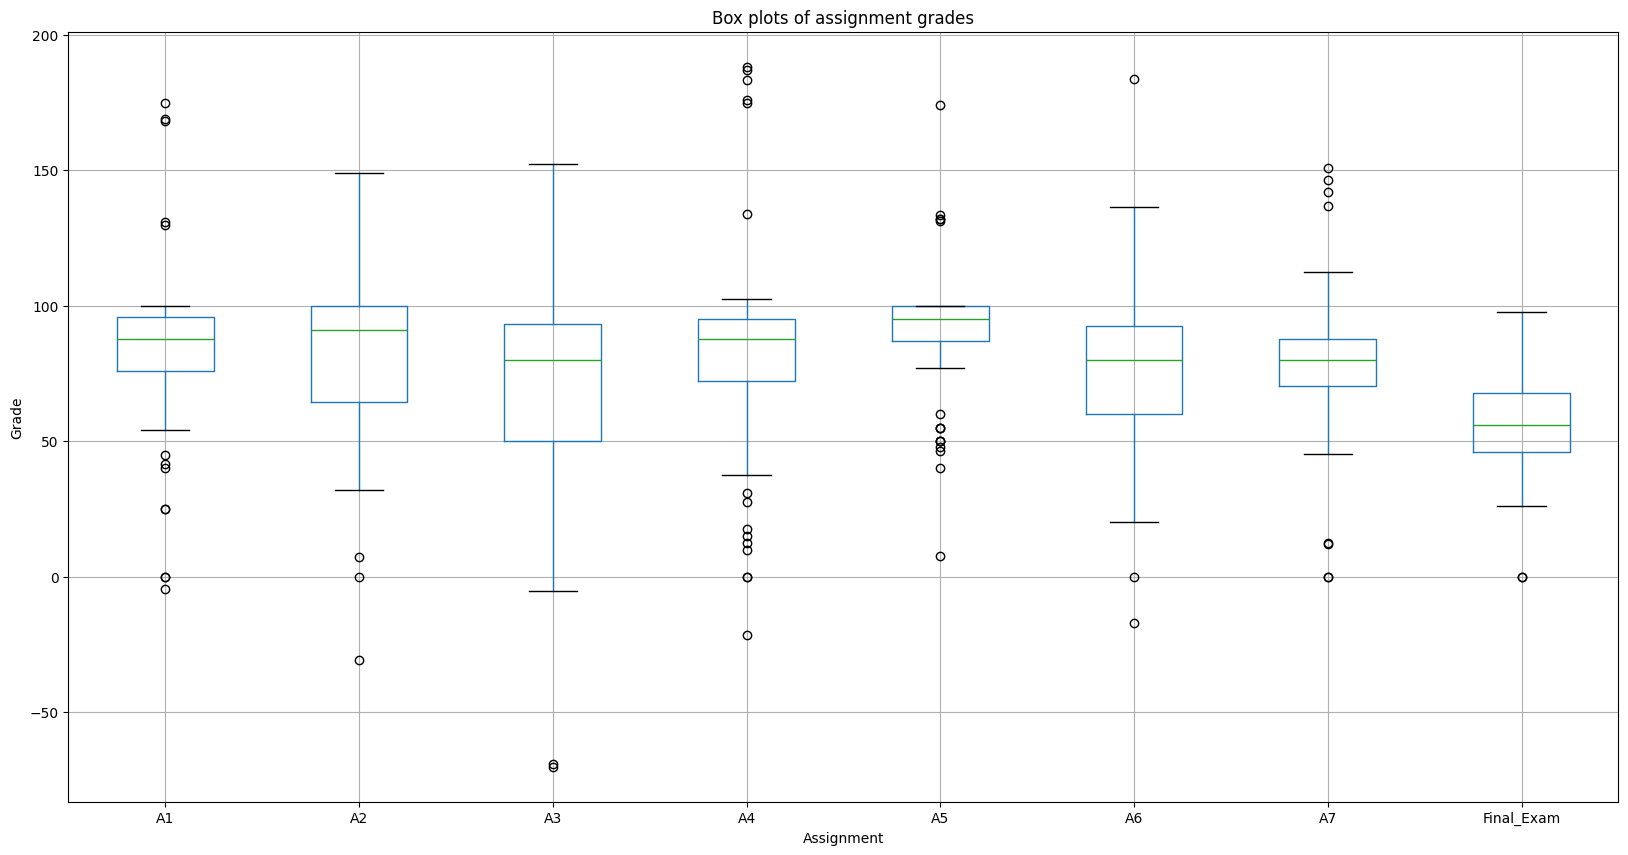

In [69]:
plt.figure(figsize=(20,10))
df_grades.boxplot(column=["A1", "A2", "A3", "A4", "A5", "A6", "A7", "Final_Exam"])
plt.title("Box plots of assignment grades")
plt.xlabel("Assignment")
plt.ylabel("Grade")
plt.show()

The outliers can be shown above which are above or below the whiskers. The outliers which are above the theoretical maximum grade, and the ones that are below zero need to be removed. Below, I will list all the unusual grades.

In [70]:
unusual_assignment1 = df_grades.loc[df_grades["A1"] < 0, df_grades["A1"] > 100]
display(unusual_assignment1)

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

### Observing correlations below

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
A1,1.000000,-0.141322,0.363341,0.299973,0.242348,0.233172,-0.020569,0.212839
A2,-0.141322,1.000000,0.209836,-0.027420,0.011602,0.356759,0.031056,0.284525
A3,0.363341,0.209836,1.000000,0.189807,0.191534,-0.032497,0.145332,0.277859
A4,0.299973,-0.027420,0.189807,1.000000,0.039064,0.146504,0.223921,0.403466
A5,0.242348,0.011602,0.191534,0.039064,1.000000,0.241590,0.031902,0.018271
A6,0.233172,0.356759,-0.032497,0.146504,0.241590,1.000000,0.147876,0.246127
A7,-0.020569,0.031056,0.145332,0.223921,0.031902,0.147876,1.000000,0.380756
Final_Exam,0.212839,0.284525,0.277859,0.403466,0.018271,0.246127,0.380756,1.000000


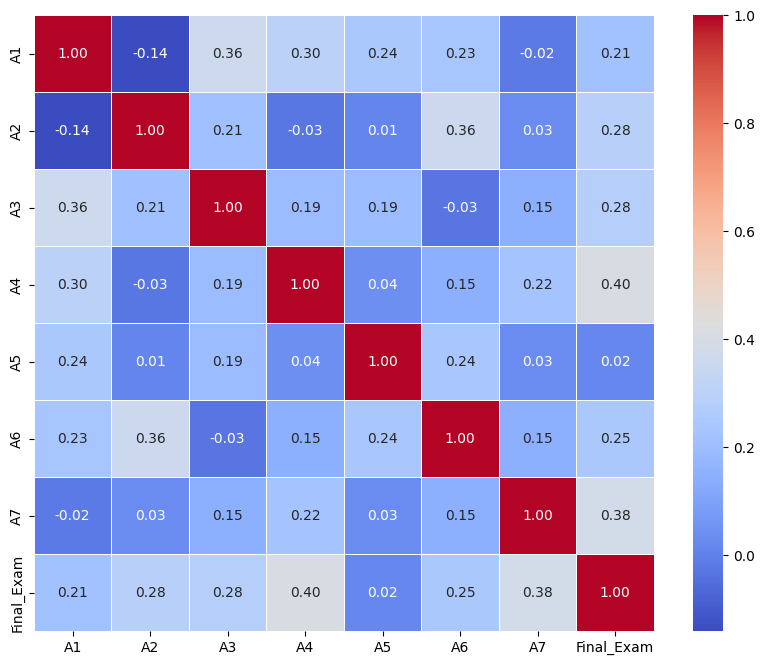

In [ ]:
assignment_columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
correlation_matrix = df_grades[assignment_columns].corr()
display (correlation_matrix)
plt.figure(figsize=(10,8 ))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()